In [1]:
# HOME_DIR='/home/jovyan/kuratov'
HOME_DIR='/home/kuratov'

%load_ext autoreload
%autoreload 2

import os
# os.chdir('/home/jovyan/kuratov/data/test_time_gd/')
os.chdir(f'{HOME_DIR}/data/test_time_gd/')

In [2]:
from pathlib import Path
import json

runs_path = Path(f'{HOME_DIR}/data/test_time_gd/runs')

runs = []
for run_path in runs_path.glob('**/*/*/run_*'):
    if run_path.is_dir():
        run_stats = {}
        run_stats['run_name'] = run_path.parent.name
        run_stats['task_name'] = run_path.parent.parent.name
        run_stats['run_id'] = int(run_path.name.split('_')[1])
        # add cli args
        run_stats.update(json.load(open(run_path / 'config.json'))['cli_args'])
        # add results
        results_path = run_path / 'all_results.json'
        if results_path.exists():
            results = json.load(open(results_path, 'r'))
            run_stats.update(results)
        runs += [run_stats]

import pandas as pd
df = pd.DataFrame(runs)
df['gradmem'] = df['run_name'].apply(lambda x: 'gradmem' in x)
df['rmt'] = df['run_name'].apply(lambda x: 'rmt' in x)
df['base_model'] = df['base_model'].fillna('gpt2')
df

,run_name,task_name,run_id,exp_path,per_device_batch_size,data_path,tokenizer_path,gradient_accumulation_steps,total_batch_size,metric_for_best_model,...,eval_inner_grad_norm,eval_inner_grad_norm_max,eval_inner_grad_norm_min,eval_inner_loss,eval_mem_norm_max,eval_mem_norm_mean,last_K_second_order,use_gradient_checkpointing,gradmem,rmt
0,pythia-160m_bs_32_lr_1e-04,babilong_qa3_0k,1,./runs/babilong_qa3_0k/pythia-160m_bs_32_lr_1e...,32,./data/babilong_qa3_0k,./tokenizers/kv_alphabet_62/,1,32,token_accuracy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
1,pythia-160m_bs_64_lr_1e-04,babilong_qa3_0k,1,./runs/babilong_qa3_0k/pythia-160m_bs_64_lr_1e...,32,./data/babilong_qa3_0k,./tokenizers/kv_alphabet_62/,2,64,token_accuracy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
2,mamba-130m-hf_bs_64_lr_1e-04,babilong_qa1_0k,1,./runs/babilong_qa1_0k/mamba-130m-hf_bs_64_lr_...,64,./data/babilong_qa1_0k,./tokenizers/kv_alphabet_62/,1,64,token_accuracy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
3,gradmem_gpt2_mem8_K2_ilr2.5_mem_proj_whead_gra...,babilong_qa1_0k,1,./runs/babilong_qa1_0k/gradmem_gpt2_mem8_K2_il...,64,./data/babilong_qa1_0k,./tokenizers/kv_alphabet_62/,1,64,token_accuracy,...,0.145823,0.608950,0.015918,12.663759,2.265932,1.703361,NaN,NaN,True,False
4,gradmem_pythia-160m_mem8_K2_ilr2.5_mem_proj_wh...,babilong_qa1_0k,1,./runs/babilong_qa1_0k/gradmem_pythia-160m_mem...,64,./data/babilong_qa1_0k,./tokenizers/kv_alphabet_62/,1,64,token_accuracy,...,0.015926,0.148730,0.002468,42.253757,1.688208,1.653801,NaN,NaN,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,gradmem_gpt2_mem8_K2_ilr1.0_mem_proj_whead_gra...,babilong_qa5_0k,1,./runs/babilong_qa5_0k/gradmem_gpt2_mem8_K2_il...,8,./data/babilong_qa5_0k,./tokenizers/kv_alphabet_62/,2,16,token_accuracy,...,0.557172,2.893186,0.053160,9.852938,3.247048,1.828127,NaN,NaN,True,False
330,gpt2_bs_64_lr_1e-04,babilong_qa5_0k,1,./runs/babilong_qa5_0k/gpt2_bs_64_lr_1e-04/run_1,64,./data/babilong_qa5_0k,./tokenizers/kv_alphabet_62/,1,64,token_accuracy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
331,pythia-160m_bs_64_lr_1e-04,babilong_qa5_0k,1,./runs/babilong_qa5_0k/pythia-160m_bs_64_lr_1e...,64,./data/babilong_qa5_0k,./tokenizers/kv_alphabet_62/,1,64,token_accuracy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
332,mamba_L4D128_bs_64_lr_1e-04,N64-K2V2-V62_noise_0.25_1M,2,./runs/N64-K2V2-V62_noise_0.25_1M/mamba_L4D128...,64,./data/N64-K2V2-V62_noise_0.25_1M,./tokenizers/kv_alphabet_62/,1,64,token_accuracy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False


In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


# group by run_name, task_name
# show mean and std of token_accuracy and exact_match
g = df.groupby(['task_name', 'run_name']).agg({
    'gradmem': 'first',
    'rmt': 'first',
    'eval_token_accuracy': ['mean', 'std', list], 
    'eval_exact_match': ['mean', 'std', list],
    'base_model': 'first',
    'K': 'first',
    'inner_lr': 'first',
    'n_mem_tokens': 'first',
    'use_adam': 'first',
    'grad_mode': 'first',
    'inner_clip_norm': 'first',
    'learning_rate': 'first',
    'n_ctrl_tokens': 'first',
    'mem_proj_mode': 'first',
    'use_write_head': 'first',
    'max_position_embeddings': 'first',
    'adam_beta2': 'first',
})
g = g.reset_index()
g = g.sort_values(by=['task_name', ('eval_token_accuracy', 'mean')], ascending=False)
# # sort run_name by eval_token_accuracy mean inside of each group, keep grouping by task_name
# g = g.groupby(level=0).apply(lambda x: x.sort_values(('eval_token_accuracy', 'mean'), ascending=False))
# g

# K ~ 1, large LR
# mem < 8
# 
# 


# !Ø:▮!!e:Ⓜ!!d:😥!!😝:🙏!|      ?!Ø:   ▮!|
# context, 1st segment          query, 2nd segment


# g[g['task_name'] == 'N4-K1V1-V512_1M']
# g[g['task_name'] == 'N4-K1V1-V62_1M']
# g[g['task_name'] == 'N4-K2V2-V62_1M']
# g[g['task_name'] == 'N4-K2V2-V512_1M']
# g[g['task_name'] == 'N8-K1V1-V512_1M']
# g[g['task_name'] == 'N8-K1V1-V62_1M']
# g[g['task_name'] == 'N8-K2V2-V512_1M']
# g[g['task_name'] == 'N8-K2V2-V62_1M']
# g[g['task_name'] == 'N8-K2V2-V62_noise_0.25_1M']
# g[g['task_name'] == 'N8-K2V2-V62_noise_0.5_1M']
# g[g['task_name'] == 'N8-K2V2-V62_noise_0.75_1M']
# g[g['task_name'] == 'N16-K1V1-V512_1M']
# g[g['task_name'] == 'N16-K1V1-V62_1M']
# g[g['task_name'] == 'N16-K2V2-V512_1M']
# g[g['task_name'] == 'N16-K2V2-V62_1M']
# g[g['task_name'] == 'N32-K1V1-V512_1M']
# g[g['task_name'] == 'N32-K1V1-V62_1M']
# g[g['task_name'] == 'N32-K2V2-V512_1M']
g[g['task_name'] == 'N32-K2V2-V62_1M']
# g[g['task_name'] == 'N64-K2V2-V62_1M']

# g[g['task_name'].str.contains('babilong_')].sort_values(by='task_name', ascending=True)
# g[g['task_name'].str.contains('squad')].sort_values(by='task_name', ascending=True)

# g[g['task_name'] == 'N2-K4V4-S4(32-64)_1M']
# g[g['task_name'] == 'N10-K2V2-S4(32-64)_1M']
# g[g['task_name'] == 'N2-K4V4-S1(16-32)_1M']

task_name  \
                      
51  N32-K2V2-V62_1M   
49  N32-K2V2-V62_1M   
45  N32-K2V2-V62_1M   
47  N32-K2V2-V62_1M   
44  N32-K2V2-V62_1M   
38  N32-K2V2-V62_1M   
41  N32-K2V2-V62_1M   
39  N32-K2V2-V62_1M   
46  N32-K2V2-V62_1M   
37  N32-K2V2-V62_1M   
35  N32-K2V2-V62_1M   
40  N32-K2V2-V62_1M   
53  N32-K2V2-V62_1M   
43  N32-K2V2-V62_1M   
52  N32-K2V2-V62_1M   
50  N32-K2V2-V62_1M   
48  N32-K2V2-V62_1M   
42  N32-K2V2-V62_1M   
30  N32-K2V2-V62_1M   
33  N32-K2V2-V62_1M   
34  N32-K2V2-V62_1M   
31  N32-K2V2-V62_1M   
36  N32-K2V2-V62_1M   
29  N32-K2V2-V62_1M   
32  N32-K2V2-V62_1M   

                                                                           run_name  \
                                                                                      
51                                                    llama_L4H4D128_bs_64_lr_1e-04   
49           gradmem_llama_L4H4D128_mem8_K5_ilr2.0_whead_grad_second_bs_64_lr_1e-04   
45          gradmem_llama_L4H4D128_mem8_K3_ilr0.04_whead_grad_second_bs_64_lr_1e-04   
47          gradmem_llama_L4H4D128_mem8_K3_ilr0.12_whead_grad_second_bs_64_lr_1e-04   
44           gradmem_llama_L4H4D128_mem8_K2_ilr5.0_whead_grad_second_bs_64_lr_1e-04   
38          gradmem_llama_L4H4D128_mem8_K2_ilr0.12_whead_grad_second_bs_64_lr_1e-04   
41  gradmem_llama_L4H4D128_mem8_K2_ilr2.5_mem_proj_whead_grad_second_bs_64_lr_1e-04   
39          gradmem_llama_L4H4D128_mem8_K2_ilr0.16_whead_grad_second_bs_64_lr_1e-04   
46          gradmem_llama_L4H4D128_mem8_K3_ilr0.08_whead_grad_second_bs_64_lr_1e-04   
37          gradmem_llama_L4H4D128_mem8_K2_ilr0.08_whead_grad_second_bs_64_lr_1e-04   
35          gradmem_llama_L4H4D128_mem8_K2_ilr0.04_whead_grad_second_bs_64_lr_1e-04   
40           gradmem_llama_L4H4D128_mem8_K2_ilr0.2_whead_grad_second_bs_64_lr_1e-04   
53                                                      mamba_L4D128_bs_64_lr_3e-04   
43  gradmem_llama_L4H4D128_mem8_K2_ilr5.0_mem_proj_whead_grad_second_bs_64_lr_1e-04   
52                                                      mamba_L4D128_bs_64_lr_1e-04   
50                                              llama_L4H4D128_L1024_bs_64_lr_1e-04   
48           gradmem_llama_L4H4D128_mem8_K5_ilr1.0_whead_grad_second_bs_64_lr_1e-04   
42           gradmem_llama_L4H4D128_mem8_K2_ilr2.5_whead_grad_second_bs_64_lr_1e-04   
30          gradmem_llama_L4H4D128_mem8_K1_ilr0.08_whead_grad_second_bs_64_lr_1e-04   
33           gradmem_llama_L4H4D128_mem8_K1_ilr0.8_whead_grad_second_bs_64_lr_1e-04   
34  gradmem_llama_L4H4D128_mem8_K2_ilr0.04_last_K1_whead_grad_second_bs_64_lr_1e-04   
31          gradmem_llama_L4H4D128_mem8_K1_ilr0.12_whead_grad_second_bs_64_lr_1e-04   
36  gradmem_llama_L4H4D128_mem8_K2_ilr0.08_last_K1_whead_grad_second_bs_64_lr_1e-04   
29          gradmem_llama_L4H4D128_mem8_K1_ilr0.04_whead_grad_second_bs_64_lr_1e-04   
32          gradmem_llama_L4H4D128_mem8_K1_ilr0.16_whead_grad_second_bs_64_lr_1e-04   

   gradmem    rmt eval_token_accuracy                                      \
     first  first                mean       std                      list   
51   False  False            0.999050  0.001344             [1.0, 0.9981]   
49    True  False            0.998100  0.000424          [0.9984, 0.9978]   
45    True  False            0.992800       NaN             [nan, 0.9928]   
47    True  False            0.992600       NaN             [nan, 0.9926]   
44    True  False            0.986950  0.001909          [0.9883, 0.9856]   
38    True  False            0.984050  0.011809          [0.9757, 0.9924]   
41    True  False            0.983650  0.002616          [0.9855, 0.9818]   
39    True  False            0.982900  0.005657          [0.9789, 0.9869]   
46    True  False            0.980900       NaN             [nan, 0.9809]   
37    True  False            0.979450  0.000212          [0.9793, 0.9796]   
35    True  False            0.978950  0.005869          [0.9748, 0.9831]   
40    True  False            0.967550

In [4]:
g[g['run_name'].str.contains('rmt2')]

task_name  \
                                 
142  N8-K2V2-V62_noise_0.75_1M   
136   N8-K2V2-V62_noise_0.5_1M   
137   N8-K2V2-V62_noise_0.5_1M   
132  N8-K2V2-V62_noise_0.25_1M   
130  N8-K2V2-V62_noise_0.25_1M   
131  N8-K2V2-V62_noise_0.25_1M   
117             N8-K2V2-V62_1M   
118             N8-K2V2-V62_1M   
120             N8-K2V2-V62_1M   
115             N8-K2V2-V62_1M   
123             N8-K2V2-V62_1M   
122             N8-K2V2-V62_1M   
119             N8-K2V2-V62_1M   
124             N8-K2V2-V62_1M   
125             N8-K2V2-V62_1M   
116             N8-K2V2-V62_1M   
121             N8-K2V2-V62_1M   
104            N8-K2V2-V512_1M   
97             N8-K1V1-V512_1M   
98             N8-K1V1-V512_1M   
70              N4-K2V2-V62_1M   
71              N4-K2V2-V62_1M   
69              N4-K2V2-V62_1M   
19             N16-K2V2-V62_1M   
17             N16-K2V2-V62_1M   
16             N16-K2V2-V62_1M   
18             N16-K2V2-V62_1M   
5             N16-K2V2-V512_1M   

                                                            run_name gradmem  \
                                                                       first   
142            rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_256_lr_1e-04   False   
136            rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_256_lr_1e-04   False   
137             rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_1e-04   False   
132             rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_5e-05   False   
130            rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_256_lr_1e-04   False   
131             rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_1e-04   False   
117            rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_256_lr_1e-04   False   
118             rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_1e-04   False   
120     rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_1e-04_b2_0.98   False   
115             rmt2segm_llama_L4H4D128_mem4_mem_proj_bs_64_lr_1e-04   False   
123          rmt2segm_llama_L4H4D128_mem8_mem_proj_rw_bs_64_lr_1e-04   False   
122             rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_5e-05   False   
119     rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_1e-04_b2_0.95   False   
124  rmt2segm_llama_L4H4D128_mem8_mem_proj_rw_bs_64_lr_1e-04_b2_0.95   False   
125            rmt2segm_pythia_L4H4D128_mem8_mem_proj_bs_64_lr_1e-04   False   
116                      rmt2segm_llama_L4H4D128_mem8_bs_64_lr_1e-04   False   
121             rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_3e-04   False   
104                      rmt2segm_llama_L4H4D128_mem8_bs_64_lr_1e-04   False   
97                       rmt2segm_llama_L4H4D128_mem8_bs_64_lr_1e-04   False   
98              rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_1e-04   False   
70                       rmt2segm_llama_L4H4D128_mem8_bs_64_lr_1e-04   False   
71              rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_1e-04   False   
69                       rmt2segm_llama_L4H4D128_mem8_bs_64_lr_1e-03   False   
19              rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_5e-05   False   
17             rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_256_lr_1e-04   False   
16                       rmt2segm_llama_L4H4D128_mem8_bs_64_lr_1e-04   False   
18              rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_1e-04   False   
5                        rmt2segm_llama_L4H4D128_mem8_bs_64_lr_1e-04   False   

      rmt eval_token_accuracy                                      \
    first                mean       std                      list   
142  True            0.169850  0.000212            [0.17, 0.1697]   
136  True            0.340200  0.243245          [0.1682, 0.5122]   
137  True            0.169100  0.000424          [0.1694, 0.1688]   
132  True            0.169500  0.000566          [0.1691, 0.1699]   
130  True            0.169450  0.001344          [0.1685, 0.1704]   
131  True            0.167450  0.002051           [0.166, 0.1689]   
117  True            0.980600  0.009192        

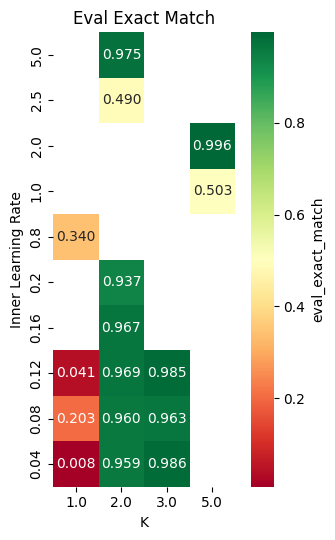

In [5]:
r = g.copy()
r = r[r['task_name'] == 'N32-K2V2-V62_1M']


# gradmem_llama_L4H4D128_mem8_K5_ilr2.0_whead_grad_second_bs_64_lr_1e-04
# gradmem_llama_L4H4D128_mem8_K{}_ilr{}_whead_grad_second_bs_64_lr_1e-04
# regular expression to match gradmem_llama_L4H4D128_mem8_K{}_ilr{}_whead_grad_second_bs_64_lr_1e-04
regexp = r'gradmem_llama_L4H4D128_mem8_K(\d+)_ilr(\d+\.\d+)_whead_grad_second_bs_64_lr_1e-04'
# find all runs that match the regular expression
r = r[r['run_name'].str.match(regexp)]


# Create heatmap with K and inner_lr on axes and eval_exact_match as values
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Extract K and inner_lr values from the matched runs
k_values = []
ilr_values = []
eval_scores = []

for idx, row in r.iterrows():
    k = row[('K', 'first')]
    ilr = row[('inner_lr', 'first')]
    eval_score = row[('eval_exact_match', 'mean')]
    
    k_values.append(k)
    ilr_values.append(ilr)
    eval_scores.append(eval_score)

# Create a pivot table for the heatmap
import pandas as pd
heatmap_data = pd.DataFrame({
    'K': k_values,
    'inner_lr': ilr_values,
    'eval_exact_match': eval_scores
})

# Pivot the data to create a matrix suitable for heatmap
pivot_table = heatmap_data.pivot_table(values='eval_exact_match', index='inner_lr', columns='K', aggfunc='mean')

# Sort the index (inner_lr) from largest to smallest
pivot_table = pivot_table.sort_index(ascending=False)

# Create the heatmap with square cells
n_rows, n_cols = pivot_table.shape
cell_size = .45  # Size of each cell in inches
fig_width = n_cols * cell_size + 2  # Add space for colorbar and labels
fig_height = n_rows * cell_size + 1  # Add space for title and labels

plt.figure(figsize=(fig_width, fig_height))
sns.heatmap(pivot_table, annot=True, cmap='RdYlGn', fmt='.3f', 
            cbar_kws={'label': 'eval_exact_match'}, square=True)
plt.title('Eval Exact Match')
plt.xlabel('K')
plt.ylabel('Inner Learning Rate')
plt.tight_layout()
plt.show()


In [6]:
r = g.copy()  #g[g['task_name'] == 'N10-K2V2-S4(32-64)_1M']
r = r[r['run_name'].str.contains('rmt2')]
# find runs with feature of interest
feature_name = 'mem_proj_mode'
feature_value = 'proj'
feature_runs = r[r[(feature_name, 'first')] == feature_value]

print(feature_runs['run_name'])

# For each run with feature of interest, find matching baseline runs with same parameters, except feature of interest
ablation_pairs = []
for idx, run in feature_runs.iterrows():
    # Define key parameters to match (excluding mem_proj_mode)
    match_params = ['task_name', 'base_model', 'gradmem', 'rmt', 'K', 'inner_lr', 'n_mem_tokens',
                    'learning_rate', 'adam_beta2', 'mem_proj_mode']
    match_params = [p for p in match_params if p != feature_name]
    
    for baseline_idx, baseline_run in r.iterrows():
        if (baseline_run['run_name'] == run['run_name']).all():
            continue
        if baseline_run[(feature_name, 'first')] == feature_value:
            continue
        # Check if all key parameters match
        params_match = True
        for param in match_params:
            if param in ['task_name']:
                if run[(param, '')] != baseline_run[(param, '')]:
                    params_match = False
                    break
            else:
                run_val = run[(param, 'first')]
                baseline_val = baseline_run[(param, 'first')]
                # Check if both are NaN/None (which should be considered equal)
                both_nan = (pd.isna(run_val) and pd.isna(baseline_val)) or (run_val is None and baseline_val is None)
                if not both_nan and (run_val != baseline_val):
                    params_match = False
                    # print(f"{param} mismatch: {run[(param, 'first')]} != {baseline_run[(param, 'first')]}")
                    break
        
        if params_match:
            ablation_pairs.append({
                'run_name': run[('run_name', '')],
                'baseline_run_name': baseline_run[('run_name', '')],
                'task_name': run[('task_name', '')],
                f'run_{feature_name}': run[(feature_name, 'first')],
                f'baseline_{feature_name}': baseline_run[(feature_name, 'first')],
                'run_acc (mean)': run[('eval_token_accuracy', 'mean')],
                'baseline_acc (mean)': baseline_run[('eval_token_accuracy', 'mean')],
                'acc_diff': run[('eval_token_accuracy', 'mean')] - baseline_run[('eval_token_accuracy', 'mean')]
            })
ablation_pairs = pd.DataFrame(ablation_pairs)
print(f'\nacc_diff: {ablation_pairs["acc_diff"].mean():.3f}+-{ablation_pairs["acc_diff"].std():.3f}\n')
# stat test to check if improved version is significantly better than baseline
from scipy import stats

# One-sample t-test to test if acc_diff is significantly greater than 0
t_stat, p_value = stats.ttest_1samp(ablation_pairs['acc_diff'], 0)
print(f"One-sample t-test (H0: acc_diff = 0, H1: acc_diff > 0)")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value (two-tailed): {p_value:.4f}")
print(f"p-value (one-tailed): {p_value/2:.4f}")
print(f"Significant improvement (p < 0.05): {p_value/2 < 0.05}")

# Also run Wilcoxon signed-rank test (non-parametric alternative)
w_stat, w_p_value = stats.wilcoxon(ablation_pairs['acc_diff'])
print(f"\nWilcoxon signed-rank test (non-parametric)")
print(f"W-statistic: {w_stat:.4f}")
print(f"p-value (two-tailed): {w_p_value:.4f}")
print(f"p-value (one-tailed): {w_p_value/2:.4f}")
print(f"Significant improvement (p < 0.05): {w_p_value/2 < 0.05}")
ablation_pairs


142           rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_256_lr_1e-04
136           rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_256_lr_1e-04
137            rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_1e-04
132            rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_5e-05
130           rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_256_lr_1e-04
131            rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_1e-04
117           rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_256_lr_1e-04
118            rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_1e-04
120    rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_1e-04_b2_0.98
115            rmt2segm_llama_L4H4D128_mem4_mem_proj_bs_64_lr_1e-04
122            rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_5e-05
119    rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_1e-04_b2_0.95
125           rmt2segm_pythia_L4H4D128_mem8_mem_proj_bs_64_lr_1e-04
121            rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_3e-04
98             rmt2segm_llama_L4H4D128_mem8_mem_

,run_name,baseline_run_name,task_name,run_mem_proj_mode,baseline_mem_proj_mode,run_acc (mean),baseline_acc (mean),acc_diff
0,rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_256_lr_1e-04,rmt2segm_llama_L4H4D128_mem8_mem_proj_rw_bs_64_lr_1e-04,N8-K2V2-V62_1M,proj,proj_rw,0.980600,0.549550,0.43105
1,rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_1e-04,rmt2segm_llama_L4H4D128_mem8_bs_64_lr_1e-04,N8-K2V2-V62_1M,proj,none,0.919500,0.168200,0.75130
2,rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_1e-04_b2_0.95,rmt2segm_llama_L4H4D128_mem8_mem_proj_rw_bs_64_lr_1e-04_b2_0.95,N8-K2V2-V62_1M,proj,proj_rw,0.448150,0.263100,0.18505
3,rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_1e-04,rmt2segm_llama_L4H4D128_mem8_bs_64_lr_1e-04,N8-K1V1-V512_1M,proj,none,0.140933,0.142533,-0.00160
4,rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_1e-04,rmt2segm_llama_L4H4D128_mem8_bs_64_lr_1e-04,N4-K2V2-V62_1M,proj,none,0.981550,0.990050,-0.00850
5,rmt2segm_llama_L4H4D128_mem8_mem_proj_bs_64_lr_1e-04,rmt2segm_llama_L4H4D128_mem8_bs_64_lr_1e-04,N16-K2V2-V62_1M,proj,none,0.114200,0.115400,-0.00120
